<a href="https://colab.research.google.com/github/hebaOrhb/00-Setup-Git/blob/master/ARTI406_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Load Dataset
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()# Display first 5 rows. If you want to display all rows, use df.head(-1)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())

df.describe(include='all')

Shape of dataset: (374, 13)

Columns:
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Data types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Cate

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


## What does the data represent?

This dataset represents information about people's sleep health and lifestyle habits.  
It includes demographic and health-related variables such as:

- Gender
- Age
- Occupation
- Sleep Duration
- Quality of Sleep
- Physical Activity Level
- Stress Level
- BMI Category
- Blood Pressure
- Heart Rate
- Daily Steps
- Sleep Disorder

The goal of the analysis is to understand sleep patterns, detect missing values and outliers, and identify which lifestyle variables may influence sleep quality and sleep disorders.

##Data Cleaning

The dataset was checked for missing values, duplicate rows, inconsistent categories, and incorrect data formats.

Cleaning was needed to make the data more consistent and easier to analyze.

In particular:
- Missing values were checked in all columns
- Duplicate rows were checked
- The "Blood Pressure" column needed to be split into systolic and diastolic values
- The "BMI Category" column needed standardization

##Before cleaning:

In [5]:
print("First 10 rows BEFORE cleaning:")
display(df.head(10))

print("\nMissing values BEFORE cleaning:")
display(df.isnull().sum().to_frame(name="Missing Values"))

print("\nUnique values in BMI Category BEFORE cleaning:")
print(df["BMI Category"].unique())

print("\nSample values in Blood Pressure BEFORE cleaning:")
print(df["Blood Pressure"].head())

First 10 rows BEFORE cleaning:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN



Missing values BEFORE cleaning:


,Missing Values
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0



Unique values in BMI Category BEFORE cleaning:
['Overweight' 'Normal' 'Obese' 'Normal Weight']

Sample values in Blood Pressure BEFORE cleaning:
0    126/83
1    125/80
2    125/80
3    140/90
4    140/90
Name: Blood Pressure, dtype: object


### Check Missing Values

In [6]:
# Check all values
print(df.isna())

     Person ID  Gender    Age  Occupation  Sleep Duration  Quality of Sleep  \
0        False   False  False       False           False             False   
1        False   False  False       False           False             False   
2        False   False  False       False           False             False   
3        False   False  False       False           False             False   
4        False   False  False       False           False             False   
..         ...     ...    ...         ...             ...               ...   
369      False   False  False       False           False             False   
370      False   False  False       False           False             False   
371      False   False  False       False           False             False   
372      False   False  False       False           False             False   
373      False   False  False       False           False             False   

     Physical Activity Level  Stress Level  BMI Cat

In [7]:
print(df.isna().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


We checked for missing values using df.isna().sum().  
The dataset contains missing values in the "Sleep Disorder" column only.  
Other columns have no missing values.

### Check duplicate rows

In [10]:
# checking duplicate rows
duplicates = df.duplicated()

print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 0


We checked for duplicate rows using df.duplicated().  
No duplicate rows were found in the dataset.

### No. of rows and columns

In [11]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (374, 13) 

number of rows:  374
number of columns:  13


### Data type of columns

In [12]:
# viewing the data types of columns
df.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


We examined data types using df.dtypes.  
Some columns were categorical (object), while others were numerical.

##Blood Pressure Cleaning

In [16]:
# Split Blood Pressure into two columns
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True)

# Convert to numeric
df['Systolic BP'] = pd.to_numeric(df['Systolic BP'])
df['Diastolic BP'] = pd.to_numeric(df['Diastolic BP'])
# Drop original column (optional but cleaner)
df = df.drop("Blood Pressure", axis=1)
# Check data types again
df.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Heart Rate,int64


The "Blood Pressure" column contained combined values (e.g., 120/80).  
We split it into two columns: Systolic BP and Diastolic BP, and converted them into numeric values for better analysis.

In [17]:
# Statistical summary
df.describe(include='all')

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374.000000,374.000000,155,374.000000,374.000000
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,NaN,NaN,2,NaN,NaN
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,NaN,NaN,Sleep Apnea,NaN,NaN
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,NaN,NaN,78,NaN,NaN
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,70.165775,6816.844920,NaN,128.553476,84.649733
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,4.135676,1617.915679,NaN,7.748118,6.161611
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,65.000000,3000.000000,NaN,115.000000,75.000000
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,68.000000,5600.000000,NaN,125.000000,80.000000
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,70.000000,7000.000000,NaN,130.000000,85.000000
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,72.000000,8000.000000,NaN,135.000000,90.000000


In [20]:
# DATA CLEANING (SAFE VERSION)


# 1) Handle Blood Pressure (only if exists)
if "Blood Pressure" in df.columns:

    df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True)

    df['Systolic BP'] = pd.to_numeric(df['Systolic BP'])
    df['Diastolic BP'] = pd.to_numeric(df['Diastolic BP'])

    df = df.drop("Blood Pressure", axis=1)


# 2) Fix BMI Category (inconsistent values)
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})


# 3) Handle missing values in Sleep Disorder
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")



# CHECK AFTER CLEANING


print("Missing values after cleaning:")
print(df.isna().sum(), "\n")

print("Unique values in BMI Category:")
print(df["BMI Category"].unique(), "\n")

print("Data types after cleaning:")
print(df.dtypes)

print("\nColumns in dataset:")
print(df.columns)

Missing values after cleaning:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic BP                0
Diastolic BP               0
dtype: int64 

Unique values in BMI Category:
['Overweight' 'Normal' 'Obese'] 

Data types after cleaning:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
Systolic BP                  int64
D

### Descriptive summary Statistics

Sleep Duration Analysis




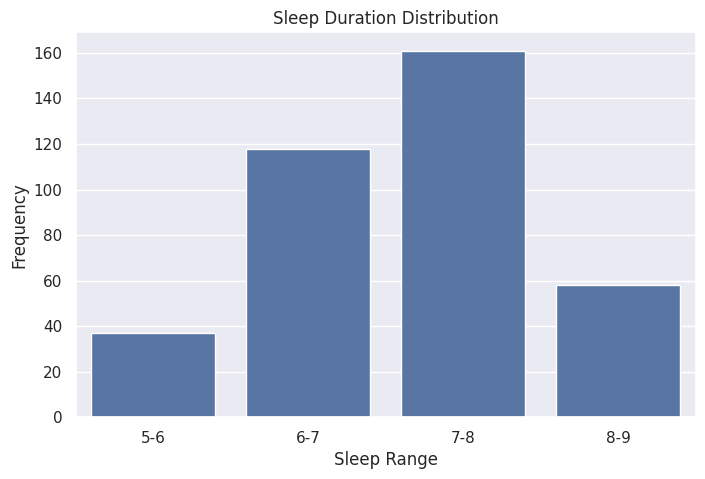

In [28]:
bins = [5, 6, 7, 8, 9]
labels = ['5-6', '6-7', '7-8', '8-9']

df['Sleep Range'] = pd.cut(df['Sleep Duration'], bins=bins, labels=labels)

counts = df['Sleep Range'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=counts.index, y=counts.values)

plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Range")
plt.ylabel("Frequency")
plt.show()

This plot was chosen to understand the distribution of sleep duration among individuals.

Most people sleep between 6–8 hours, indicating a normal sleep pattern.

This suggests that the majority of individuals maintain a healthy sleep routine.

###Sleep Disorder Distribution

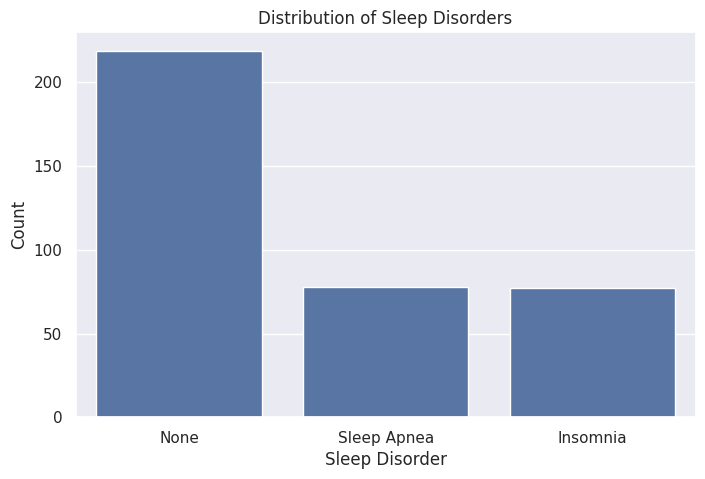

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sleep Disorder', data=df)
plt.title("Distribution of Sleep Disorders")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")
plt.show()

This plot was chosen to examine the prevalence of sleep disorders in the dataset.

The majority of individuals do not have sleep disorders, while insomnia and sleep apnea appear less frequently.

This suggests that most individuals in the dataset have normal sleep health.

## Bivariate Analysis

### Average Daily Steps by Occupation

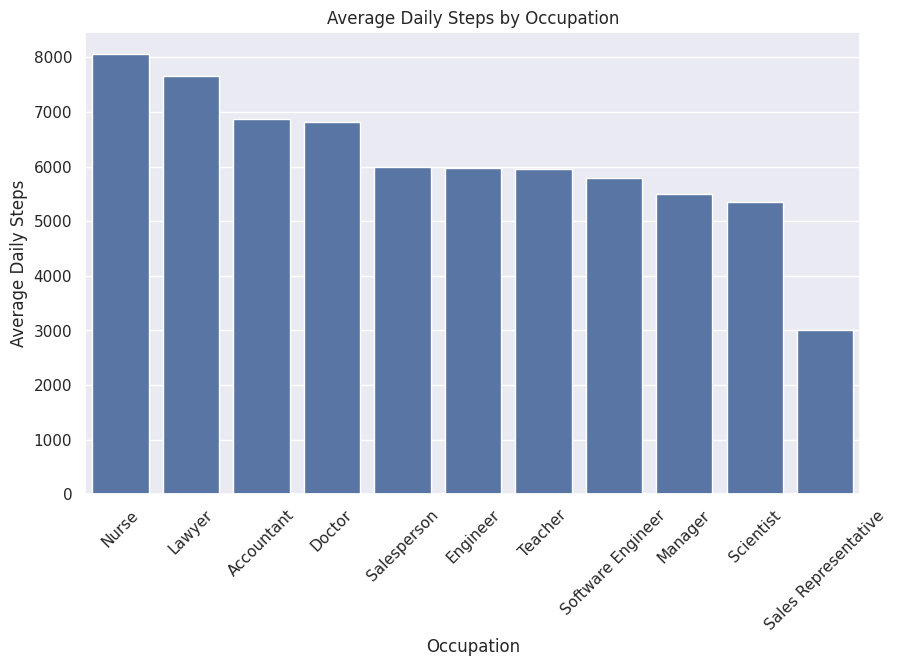

In [31]:
occupation_steps = df.groupby('Occupation')['Daily Steps'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=occupation_steps.index, y=occupation_steps.values)
plt.title("Average Daily Steps by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Average Daily Steps")
plt.xticks(rotation=45)
plt.show()

This plot was chosen to compare physical activity levels across different occupations.

The chart shows that activity levels vary significantly between jobs. Nurses have the highest average daily steps, while sales representatives have the lowest.

This suggests that physically demanding jobs lead to higher daily activity levels compared to sedentary jobs.

Average Quality of Sleep by BMI Category

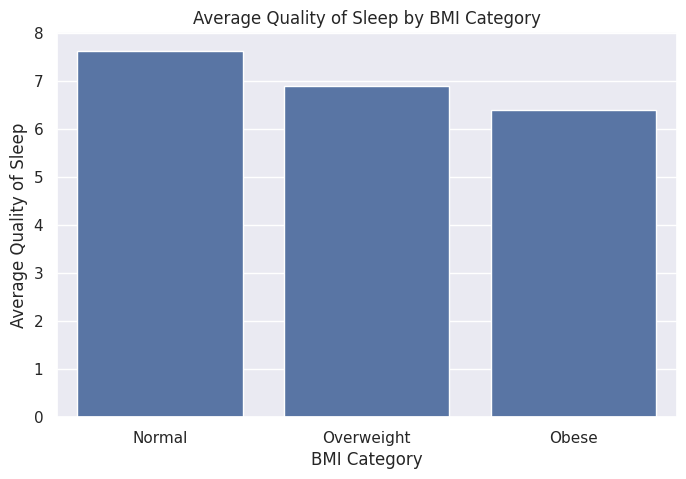

In [32]:
bmi_sleep = df.groupby('BMI Category')['Quality of Sleep'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=bmi_sleep.index, y=bmi_sleep.values)
plt.title("Average Quality of Sleep by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Average Quality of Sleep")
plt.show()

This plot was chosen to analyze how sleep quality varies across BMI categories.

The chart shows that individuals with normal BMI have the highest sleep quality, while obese individuals have the lowest.

This suggests that higher BMI may be associated with poorer sleep quality.

### Average Daily Steps by Occupation




In [45]:
steps_by_occ = df.groupby('Occupation')['Daily Steps'].mean().sort_values(ascending=False)

steps_by_occ.head()

,Daily Steps
Occupation,
Nurse,8057.534247
Lawyer,7661.702128
Accountant,6881.081081
Doctor,6808.450704
Salesperson,6000.000000


Shows average steps for each occupation  
Some jobs are more physically active than others  

### Physical Activity vs Sleep Quality


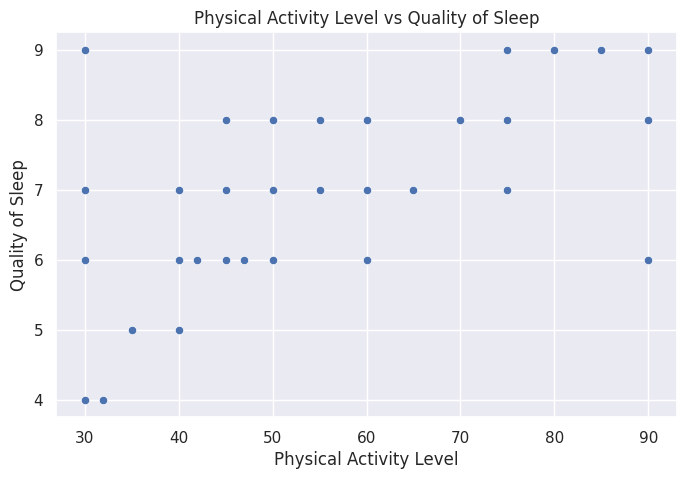

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Physical Activity Level', y='Quality of Sleep', data=df)
plt.title("Physical Activity Level vs Quality of Sleep")
plt.xlabel("Physical Activity Level")
plt.ylabel("Quality of Sleep")
plt.show()

This plot was chosen to examine the relationship between physical activity level and sleep quality.

The chart shows a positive relationship, where individuals with higher physical activity levels tend to have better sleep quality.

This suggests that increasing physical activity may lead to improved sleep quality.



### Sleep Duration by Age





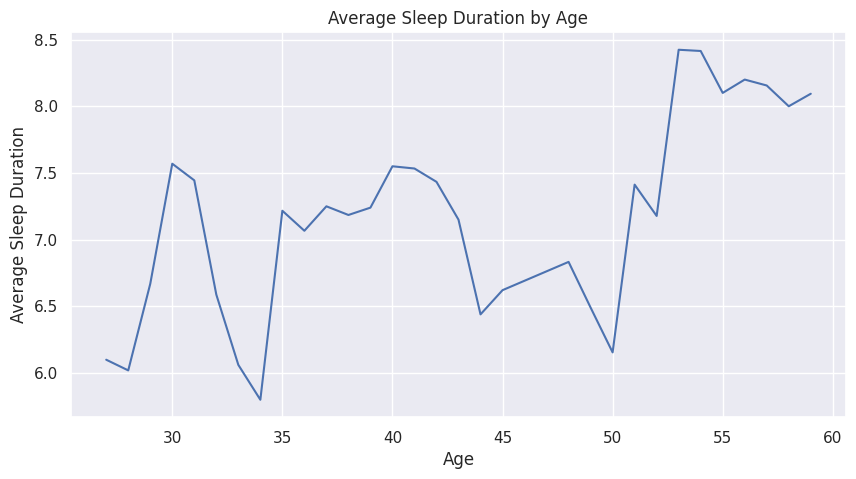

In [42]:
age_sleep = df.groupby('Age')['Sleep Duration'].mean()

plt.figure(figsize=(10,5))
plt.plot(age_sleep.index, age_sleep.values)

plt.title("Average Sleep Duration by Age")
plt.xlabel("Age")
plt.ylabel("Average Sleep Duration")
plt.show()

This plot was chosen to analyze how sleep duration changes with age.

The chart shows slight variations in sleep duration across different ages, with no strong increasing or decreasing trend.

This suggests that age may not have a significant impact on sleep duration in this dataset.

### Correlation Analysis

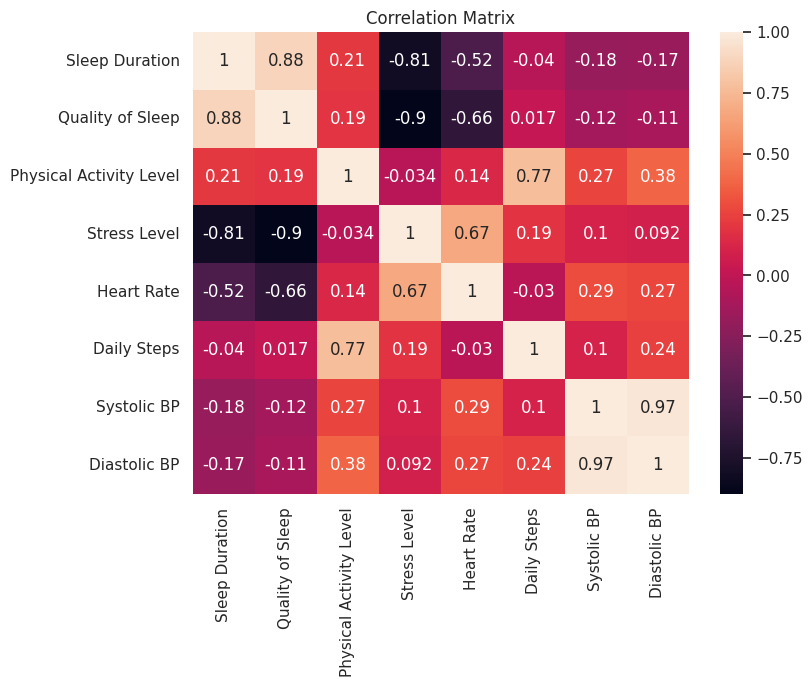

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                'Stress Level', 'Heart Rate', 'Daily Steps',
                'Systolic BP', 'Diastolic BP']].corr(),
            annot=True)

plt.title("Correlation Matrix")
plt.show()

This plot was chosen to examine the relationships between multiple numerical variables.

The heatmap shows the correlation between features such as sleep duration, sleep quality, physical activity, and stress level. Some variables show moderate relationships, while others have weak correlations.

This suggests that certain factors, such as physical activity and stress, may influence sleep quality, while other variables have less impact.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
